# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1D Diffusion Equation D1Q2

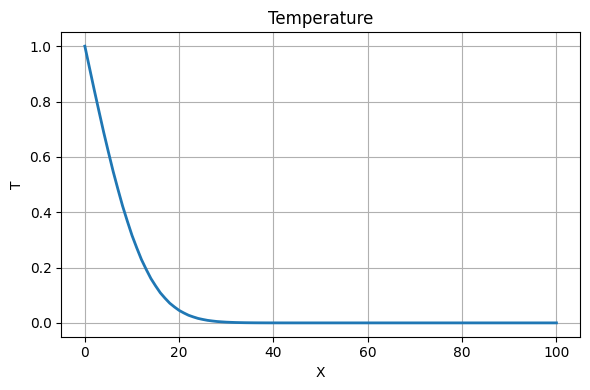

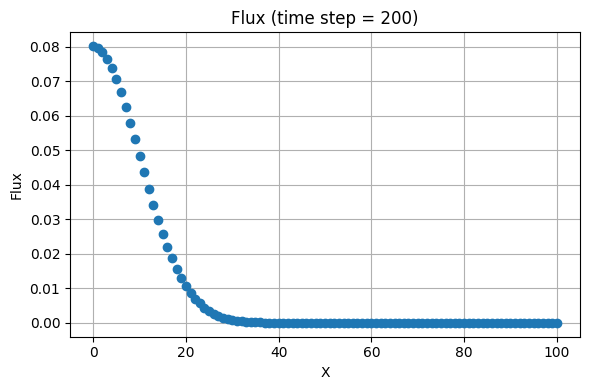

In [2]:
# ==========================================================
# Lattice Boltzmann Method (LBM)
# 1D Diffusion Equation (D1Q2)
# ==========================================================

# -----------------------
# Simulation parameters
# -----------------------
m = 101                  # Number of lattice nodes
dx = 1.0                 # Lattice spacing
alpha = 0.25             # Diffusion coefficient
omega = 1.0 / (alpha + 0.5)
twall = 1.0              # Left wall temperature
nstep = 200              # Number of time steps

# -----------------------
# Grid
# -----------------------
x = np.arange(m) * dx

# -----------------------
# Initialize variables
# -----------------------
rho = np.zeros(m)
f1 = 0.5 * rho.copy()
f2 = 0.5 * rho.copy()

# ==========================================================
# Time marching
# ==========================================================
for _ in range(nstep):

    # -------------------
    # Collision
    # -------------------
    feq = 0.5 * rho
    f1 = (1.0 - omega) * f1 + omega * feq
    f2 = (1.0 - omega) * f2 + omega * feq

    # -------------------
    # Streaming
    # -------------------
    f1[1:] = f1[:-1]      # Right-moving population
    f2[:-1] = f2[1:]      # Left-moving population

    # -------------------
    # Boundary conditions
    # -------------------
    # Left wall (constant temperature)
    f1[0] = twall - f2[0]

    # Right wall (zero-gradient)
    f1[-1] = f1[-2]
    f2[-1] = f2[-2]

    # -------------------
    # Macroscopic variable
    # -------------------
    rho = f1 + f2

# ==========================================================
# Flux
# ==========================================================
flux = omega * (f1 - f2)

# ==========================================================
# Plot Temperature
# ==========================================================
plt.figure(figsize=(6,4))
plt.plot(x, rho, linewidth=2)
plt.title("Temperature")
plt.xlabel("X")
plt.ylabel("T")
plt.grid(True)
plt.tight_layout()

# ==========================================================
# Plot Flux
# ==========================================================
plt.figure(figsize=(6,4))
plt.plot(x, flux, 'o')
plt.title(f"Flux (time step = {nstep})")
plt.xlabel("X")
plt.ylabel("Flux")
plt.grid(True)
plt.tight_layout()

plt.show()

1D Diffusion Equation D1Q3

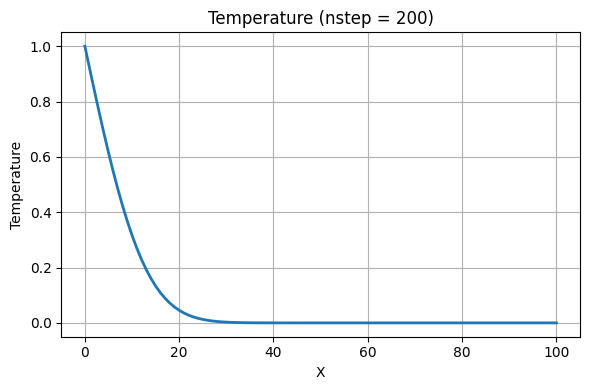

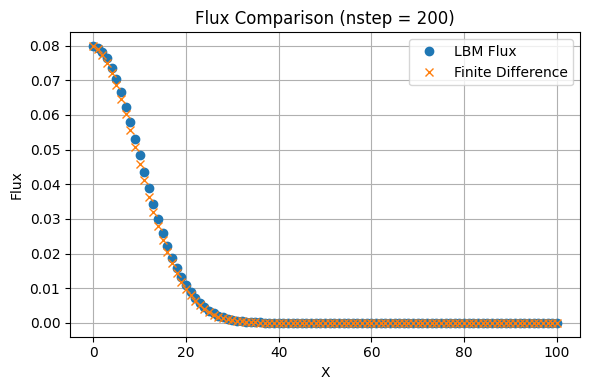

In [3]:
# ==========================================================
# Lattice Boltzmann Method (LBM)
# 1D Diffusion Equation (D1Q3)
# ==========================================================

# ----------------------------------------------------------
# Simulation parameters
# ----------------------------------------------------------
m = 101                    # Number of lattice nodes
dx = 1.0                   # Lattice spacing

# Lattice weights
w0 = 4.0 / 6.0
w1 = 1.0 / 6.0
w2 = w1

c2 = 1.0 / 3.0

alpha = 0.25               # Diffusion coefficient
omega = 1.0 / (3.0 * alpha + 0.5)

twall = 1.0                # Left wall temperature
nstep = 200                # Number of time steps

# ----------------------------------------------------------
# Grid
# ----------------------------------------------------------
x = np.arange(m) * dx

# ----------------------------------------------------------
# Initialize macroscopic and distribution functions
# ----------------------------------------------------------
rho = np.zeros(m)

f0 = w0 * rho.copy()       # Rest particles
f1 = w1 * rho.copy()       # Right-moving particles
f2 = w2 * rho.copy()       # Left-moving particles

# ==========================================================
# Time integration
# ==========================================================
for _ in range(nstep):

    # ------------------------------------------------------
    # Collision
    # ------------------------------------------------------
    feq0 = w0 * rho
    feq = w1 * rho

    f0 = (1.0 - omega) * f0 + omega * feq0
    f1 = (1.0 - omega) * f1 + omega * feq
    f2 = (1.0 - omega) * f2 + omega * feq

    # ------------------------------------------------------
    # Streaming
    # ------------------------------------------------------
    f1_old = f1.copy()
    f2_old = f2.copy()

    # Right-moving particles
    f1[1:] = f1_old[:-1]

    # Left-moving particles
    f2[:-1] = f2_old[1:]

    # f0 does not stream

    # ------------------------------------------------------
    # Boundary conditions
    # ------------------------------------------------------
    # Left boundary (constant temperature)
    f1[0] = twall - f2[0] - f0[0]

    # Right boundary (zero-gradient)
    f0[-1] = f0[-2]
    f1[-1] = f1[-2]
    f2[-1] = f2[-2]

    # ------------------------------------------------------
    # Macroscopic temperature
    # ------------------------------------------------------
    rho = f0 + f1 + f2

# ==========================================================
# Compute flux
# ==========================================================
flux = omega * (f1 - f2) / c2

# Finite-difference approximation for comparison
flux_fd = np.empty(m)
flux_fd[:-1] = rho[:-1] - rho[1:]
flux_fd[-1] = flux_fd[-2]

# ==========================================================
# Plot temperature
# ==========================================================
plt.figure(figsize=(6, 4))
plt.plot(x, rho, linewidth=2)
plt.title(f"Temperature (nstep = {nstep})")
plt.xlabel("X")
plt.ylabel("Temperature")
plt.grid(True)
plt.tight_layout()

# ==========================================================
# Plot flux comparison
# ==========================================================
plt.figure(figsize=(6, 4))
plt.plot(x, flux, 'o', label='LBM Flux')
plt.plot(x, flux_fd, 'x', label='Finite Difference')
plt.title(f"Flux Comparison (nstep = {nstep})")
plt.xlabel("X")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# 1D Diffusion Equation D1Q3 with Flux Boundary Condition

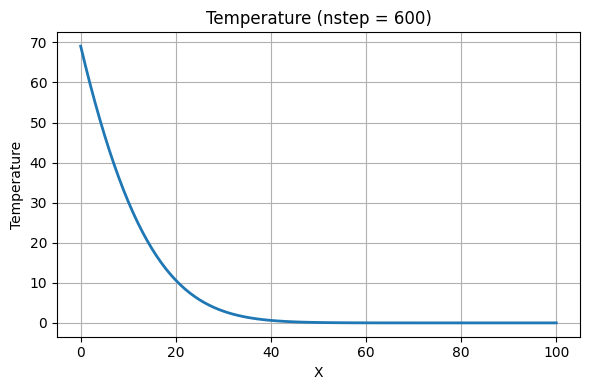

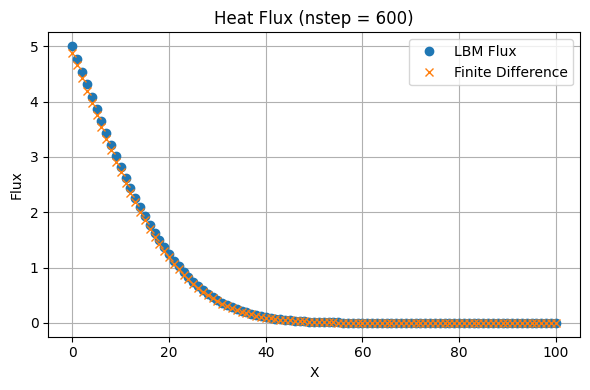

In [4]:
# ==========================================================
# Lattice Boltzmann Method (LBM)
# 1D Diffusion Equation (D1Q3)
# Heat Flux (Neumann) Boundary Condition
# ==========================================================

# ----------------------------------------------------------
# Simulation parameters
# ----------------------------------------------------------
m = 101                     # Number of lattice nodes
dx = 1.0                    # Lattice spacing

# Lattice weights
w0 = 4.0 / 6.0
w1 = 1.0 / 6.0
w2 = w1

c2 = 1.0 / 3.0              # Lattice sound speed squared

alpha = 0.25                # Diffusion coefficient
omega = 1.0 / (3.0 * alpha + 0.5)

# Heat flux boundary parameters
qf = 100.0                  # Prescribed heat flux
tk = 20.0                   # Thermal conductivity

nstep = 600                 # Number of time steps

# ----------------------------------------------------------
# Grid
# ----------------------------------------------------------
x = np.arange(m) * dx

# ----------------------------------------------------------
# Initialize macroscopic variable
# ----------------------------------------------------------
rho = np.zeros(m)

# Distribution functions
f0 = w0 * rho.copy()
f1 = w1 * rho.copy()
f2 = w2 * rho.copy()

# ==========================================================
# Time integration
# ==========================================================
for _ in range(nstep):

    # ------------------------------------------------------
    # Collision
    # ------------------------------------------------------
    feq0 = w0 * rho
    feq = w1 * rho

    f0 = (1.0 - omega) * f0 + omega * feq0
    f1 = (1.0 - omega) * f1 + omega * feq
    f2 = (1.0 - omega) * f2 + omega * feq

    # ------------------------------------------------------
    # Streaming
    # ------------------------------------------------------
    f1_old = f1.copy()
    f2_old = f2.copy()

    # Right-moving population
    f1[1:] = f1_old[:-1]

    # Left-moving population
    f2[:-1] = f2_old[1:]

    # f0 remains at the same node

    # ------------------------------------------------------
    # Boundary conditions
    # ------------------------------------------------------

    # Left boundary (prescribed heat flux)
    f1[0] = f2[0] + c2 * qf / (tk * omega)

    # Right boundary (zero-gradient)
    f0[-1] = f0[-2]
    f1[-1] = f1[-2]
    f2[-1] = f2[-2]

    # ------------------------------------------------------
    # Macroscopic temperature
    # ------------------------------------------------------
    rho = f0 + f1 + f2

# ==========================================================
# Compute heat flux
# ==========================================================
flux = omega * (f1 - f2) / c2

# Finite-difference approximation
flux_fd = np.empty(m)
flux_fd[:-1] = rho[:-1] - rho[1:]
flux_fd[-1] = flux_fd[-2]

# ==========================================================
# Plot temperature
# ==========================================================
plt.figure(figsize=(6, 4))
plt.plot(x, rho, linewidth=2)

plt.title(f"Temperature (nstep = {nstep})")
plt.xlabel("X")
plt.ylabel("Temperature")

plt.grid(True)
plt.tight_layout()

# ==========================================================
# Plot heat flux
# ==========================================================
plt.figure(figsize=(6, 4))

plt.plot(x, flux, 'o', label='LBM Flux')
plt.plot(x, flux_fd, 'x', label='Finite Difference')

plt.title(f"Heat Flux (nstep = {nstep})")
plt.xlabel("X")
plt.ylabel("Flux")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# 1D Diffusion Equation D1Q3 with Source Term



# 1D Diffusion Equation D1Q3 with Variable Alpha

# 2D Diffusion Equation D2Q5

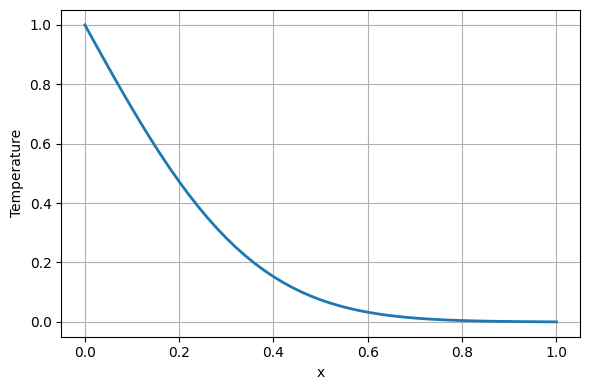

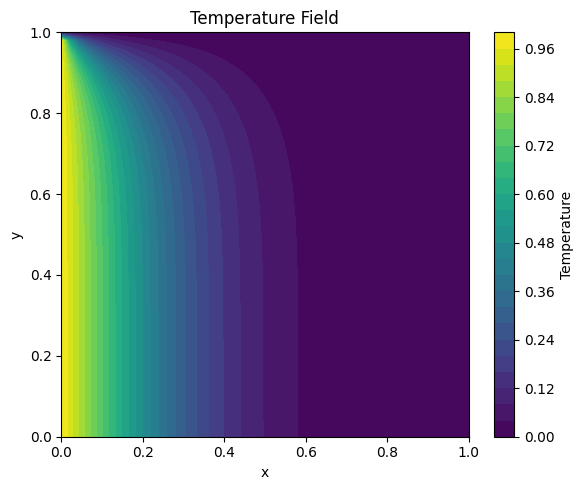

In [5]:
# ==========================================================
# LBM D2Q5
# 2D Diffusion Equation
# ==========================================================

# ----------------------------------------------------------
# Domain
# ----------------------------------------------------------
m = 51
n = 51

xl = 1.0
yl = 1.0

dx = xl / (m - 1)
dy = yl / (n - 1)

x = np.arange(m) * dx
y = np.arange(n) * dy

# ----------------------------------------------------------
# Lattice constants
# ----------------------------------------------------------
w0 = 2.0 / 6.0
w = 1.0 / 6.0

c2 = 1.0 / 3.0

alpha = 0.25
omega = 1.0 / (3.0 * alpha + 0.5)

twall = 1.0
nstep = 400

# ----------------------------------------------------------
# Macroscopic variable
# ----------------------------------------------------------
rho = np.zeros((m, n))

# Distribution functions
f0 = w0 * rho.copy()

f1 = w * rho.copy()      # east
f2 = w * rho.copy()      # west
f3 = w * rho.copy()      # north
f4 = w * rho.copy()      # south

# ==========================================================
# Time integration
# ==========================================================

for _ in range(nstep):

    # ------------------------------------------------------
    # Collision
    # ------------------------------------------------------

    feq0 = w0 * rho
    feq = w * rho

    f0 = (1.0 - omega) * f0 + omega * feq0
    f1 = (1.0 - omega) * f1 + omega * feq
    f2 = (1.0 - omega) * f2 + omega * feq
    f3 = (1.0 - omega) * f3 + omega * feq
    f4 = (1.0 - omega) * f4 + omega * feq

    # ------------------------------------------------------
    # Streaming
    # ------------------------------------------------------

    f1_old = f1.copy()
    f2_old = f2.copy()
    f3_old = f3.copy()
    f4_old = f4.copy()

    # East
    f1[1:, :] = f1_old[:-1, :]

    # West
    f2[:-1, :] = f2_old[1:, :]

    # North
    f3[:, 1:] = f3_old[:, :-1]

    # South
    f4[:, :-1] = f4_old[:, 1:]

    # ------------------------------------------------------
    # Boundary conditions
    # ------------------------------------------------------

    # Left wall (constant temperature)

    f1[0, :] = (
        twall
        - f0[0, :]
        - f2[0, :]
        - f3[0, :]
        - f4[0, :]
    )

    # Right wall

    f3[-1, :] = (
        -f0[-1, :]
        -f1[-1, :]
        -f2[-1, :]
        -f4[-1, :]
    )

    # Bottom wall

    f3[:, 0] = f3[:, 1]

    # Top wall

    f4[:, -1] = (
        -f0[:, -1]
        -f1[:, -1]
        -f2[:, -1]
        -f3[:, -1]
    )

    # ------------------------------------------------------
    # Macroscopic temperature
    # ------------------------------------------------------

    rho = f0 + f1 + f2 + f3 + f4

# ==========================================================
# Midline temperature
# ==========================================================

Tm = rho[:, n // 2]

# ==========================================================
# Plot temperature along centerline
# ==========================================================

plt.figure(figsize=(6,4))

plt.plot(x, Tm, linewidth=2)

plt.xlabel("x")
plt.ylabel("Temperature")

plt.grid(True)
plt.tight_layout()

# ==========================================================
# Temperature contour
# ==========================================================

plt.figure(figsize=(6,5))

plt.contourf(
    x,
    y,
    rho.T,
    levels=30,
)

plt.colorbar(label="Temperature")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Temperature Field")

plt.tight_layout()

plt.show()

# 2D Diffusion Equation D2Q9